# Time-Aware GAT with Status Embedding — Next-Event Prediction on Helpdesk

This notebook demonstrates the **most complete model variant**: a Dual-GAT that combines
**exponential time-decay attention** with **learned edge-type (status) embeddings**.

## Model overview

| Component | Description |
|-----------|-------------|
| Architecture | Dual-GAT with custom `TimeAwareETGATConv` |
| Time decay | α′ = (α + edge_type_score) · exp(−λ Δt) |
| Edge-type embedding | Transition types are embedded and contribute an additive score to attention |
| Attention output | Returns attention, decay, **and** edge-type scores for analysis |

This variant captures both **temporal dynamics** (via decay) and
**transition semantics** (via edge-type embedding) in a single attention mechanism.

> **Note:** Helpdesk has only one lifecycle status (`complete`), so edge-type diversity is
> limited. See the BPI 2012 version for richer transition types.

### Notebook outline
1. Load & Explore the Dataset
2. Train the Model
3. Evaluate with Comprehensive Metrics
4. Attention Analysis & Visualisations
5. Summary

In [1]:
from pathlib import Path
import sys, warnings

root = Path.cwd().resolve()
src = root / "src" if (root / "src").exists() else root.parent / "src"
sys.path.insert(0, str(src))
warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Load & Explore the Dataset

In [2]:
import pandas as pd

data_dir = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd() / "examples" / "data"
df = pd.read_csv(data_dir / "Helpdesk.csv")

df = df.rename(columns={
    "case:concept:name": "case_id",
    "concept:name":      "event",
    "time:timestamp":    "time",
    "lifecycle:transition": "status",
    "case:variant-index":   "variant_index",
})
df = df.dropna(subset=["case_id", "event", "time"]).copy()
df["time"] = pd.to_datetime(df["time"], utc=True)
df = df[df.groupby("case_id")["case_id"].transform("size") >= 2].reset_index(drop=True)

print(f"Cases: {df['case_id'].nunique()}  |  Events: {len(df)}  |  Activities: {df['event'].nunique()}")
print(f"Status values: {df['status'].unique().tolist()}")
df.head()

Cases: 4580  |  Events: 21348  |  Activities: 14
Status values: ['complete']


,event,status,org:resource,time,Activity,Resource,case_id,case:variant,variant_index,case:creator
0,Assign seriousness,complete,Value 2,2010-01-13 08:40:25+00:00,Assign seriousness,Value 2,Case3608,Variant 33,33,Fluxicon Disco
1,Take in charge ticket,complete,Value 2,2010-01-29 08:52:27+00:00,Take in charge ticket,Value 2,Case3608,Variant 33,33,Fluxicon Disco
2,Resolve ticket,complete,Value 2,2010-01-29 08:52:34+00:00,Resolve ticket,Value 2,Case3608,Variant 33,33,Fluxicon Disco
3,Closed,complete,Value 5,2010-02-13 08:52:48+00:00,Closed,Value 5,Case3608,Variant 33,33,Fluxicon Disco
4,Closed,complete,Value 5,2010-02-13 08:52:48+00:00,Closed,Value 5,Case3608,Variant 33,33,Fluxicon Disco


## 2. Train the Model

`gat_time_decay_status` requires `status_col` (for edge-type embedding)
and internally uses `TimeAwareETGATConv` with learnable λ decay.

In [3]:
from timegnn import gat_time_decay_status

result = gat_time_decay_status(
    df,
    case_col="case_id",
    event_col="event",
    time_col="time",
    status_col="status",
    cat_event=["event"],
    num_event=[],
    seq_cols=["variant_index"],
    cat_seq=[],
    num_seq=["variant_index"],
    num_epochs=3,
    batch_size=16,
)

model = result["model"]
pd.DataFrame(result["history"])

,epoch,train_loss,train_acc,test_loss,test_acc
0,1,1.420802,0.639665,1.277842,0.656660
1,2,1.188128,0.708623,1.251591,0.658884
2,3,1.071267,0.712539,1.115192,0.665555


## 3. Evaluate with Comprehensive Metrics

In [4]:
import torch
from torch.utils.data import DataLoader
from timegnn import (
    EventLogTransformer, top_k_accuracy, predict, predict_per_sequence,
    average_bleu_score, compute_dls_and_exact_match, analyze_sequence_errors,
)
from timegnn.data.pyg import CustomDataset, custom_collate_fn

transformer = EventLogTransformer(
    case_col="case_id", event_col="event", time_col="time",
    status_col="status",
    cat_event=["event"], num_event=[],
    seq_cols=["variant_index"], cat_seq=[], num_seq=["variant_index"],
    mode="gat_time_decay_status",
).fit(df)

transformed = transformer.transform(df)
dataset = CustomDataset(transformed.event_features, transformed.labels)
loader  = DataLoader(dataset, batch_size=16, shuffle=False, collate_fn=custom_collate_fn)

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(device)

preds_flat, labels_flat, outputs = predict(model, loader, device)
print(f"Top-1 accuracy: {top_k_accuracy(outputs, labels_flat, k=1):.4f}")
print(f"Top-3 accuracy: {top_k_accuracy(outputs, labels_flat, k=3):.4f}")
print(f"Top-5 accuracy: {top_k_accuracy(outputs, labels_flat, k=5):.4f}")

preds_seq, labels_seq = predict_per_sequence(model, loader, device)
bleu = average_bleu_score(preds_seq, labels_seq)
dls, exact = compute_dls_and_exact_match(preds_seq, labels_seq)
print(f"\nBLEU:  {bleu:.4f}")
print(f"DLS:   {dls:.4f}")
print(f"Exact: {exact:.4f}")

print("\nSequence error summary:")
print(analyze_sequence_errors(model, loader, device))

Top-1 accuracy: 0.7081
Top-3 accuracy: 0.9527
Top-5 accuracy: 0.9926

BLEU:  0.2439
DLS:   0.7107
Exact: 0.0083

Sequence error summary:
(array([ 868, 4063,  667,  309,  184,   73,   30,   18,    9,    5,    4,
          1]), {(12, 10): 3075, (12, 8): 81, (12, 0): 550, (12, 14): 1143, (12, 1): 251, (10, 12): 369, (1, 10): 165, (14, 12): 27, (10, 2): 14, (14, 2): 5, (14, 10): 86, (10, 14): 183, (1, 12): 96, (12, 11): 3, (12, 2): 41, (10, 1): 11, (14, 8): 14, (10, 8): 15, (0, 14): 1, (10, 4): 12, (4, 1): 14, (0, 12): 14, (12, 7): 1, (12, 5): 1, (8, 10): 4, (10, 9): 5, (8, 12): 4, (4, 12): 2, (4, 10): 2, (8, 14): 4, (1, 8): 3, (3, 10): 3, (1, 14): 1, (7, 1): 1, (14, 0): 1, (8, 2): 5, (8, 9): 2, (1, 4): 6, (14, 4): 1, (12, 9): 2, (12, 4): 3, (14, 11): 1, (1, 7): 1, (4, 5): 1, (10, 13): 2, (13, 1): 1, (8, 11): 1, (1, 2): 1, (12, 3): 1, (14, 9): 1}, {'min': 2, 'max': 15, 'mean': np.float64(4.661135371179039), 'median': np.float64(4.0)})


## 4. Attention Analysis & Visualisations

This model records **three signal components** per edge:
- `attention` — standard GAT attention score
- `decay` — time-based exponential decay factor
- `edge_type_score` — learned edge-type contribution

We visualise importance heatmaps, rank dominance, temporal timelines,
and the **correlation between edge-type scores and attention weights**.

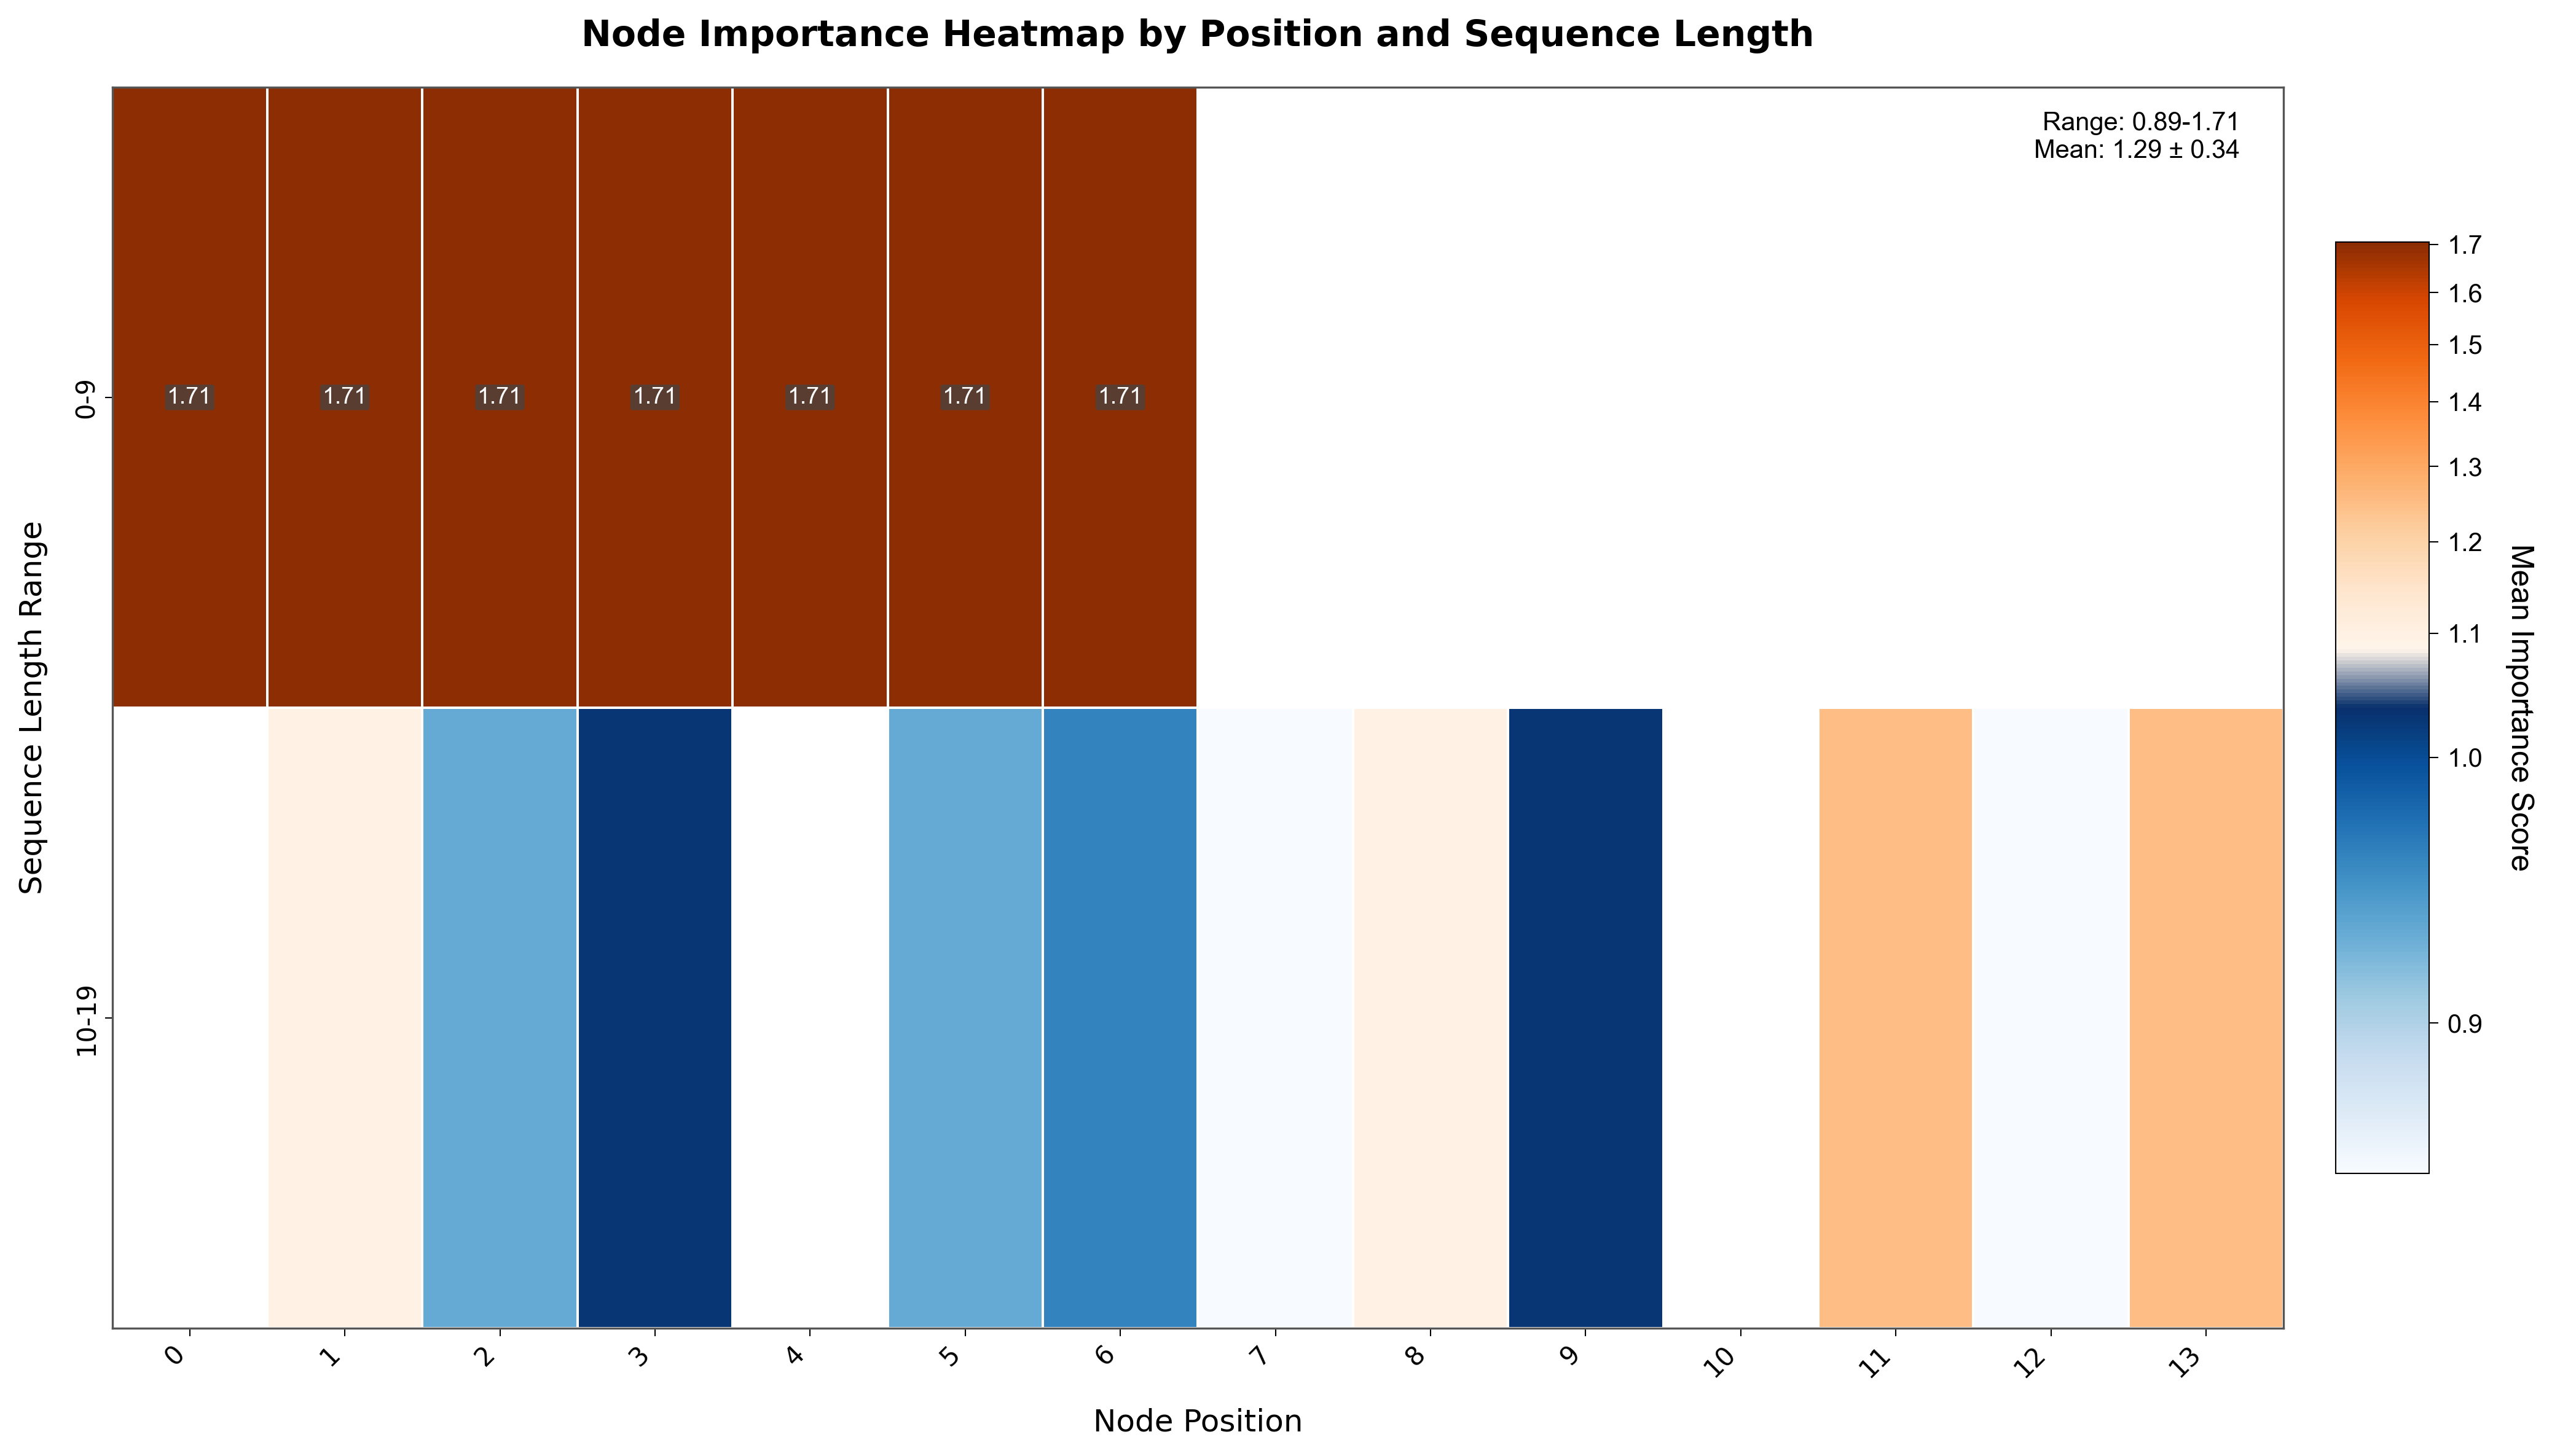

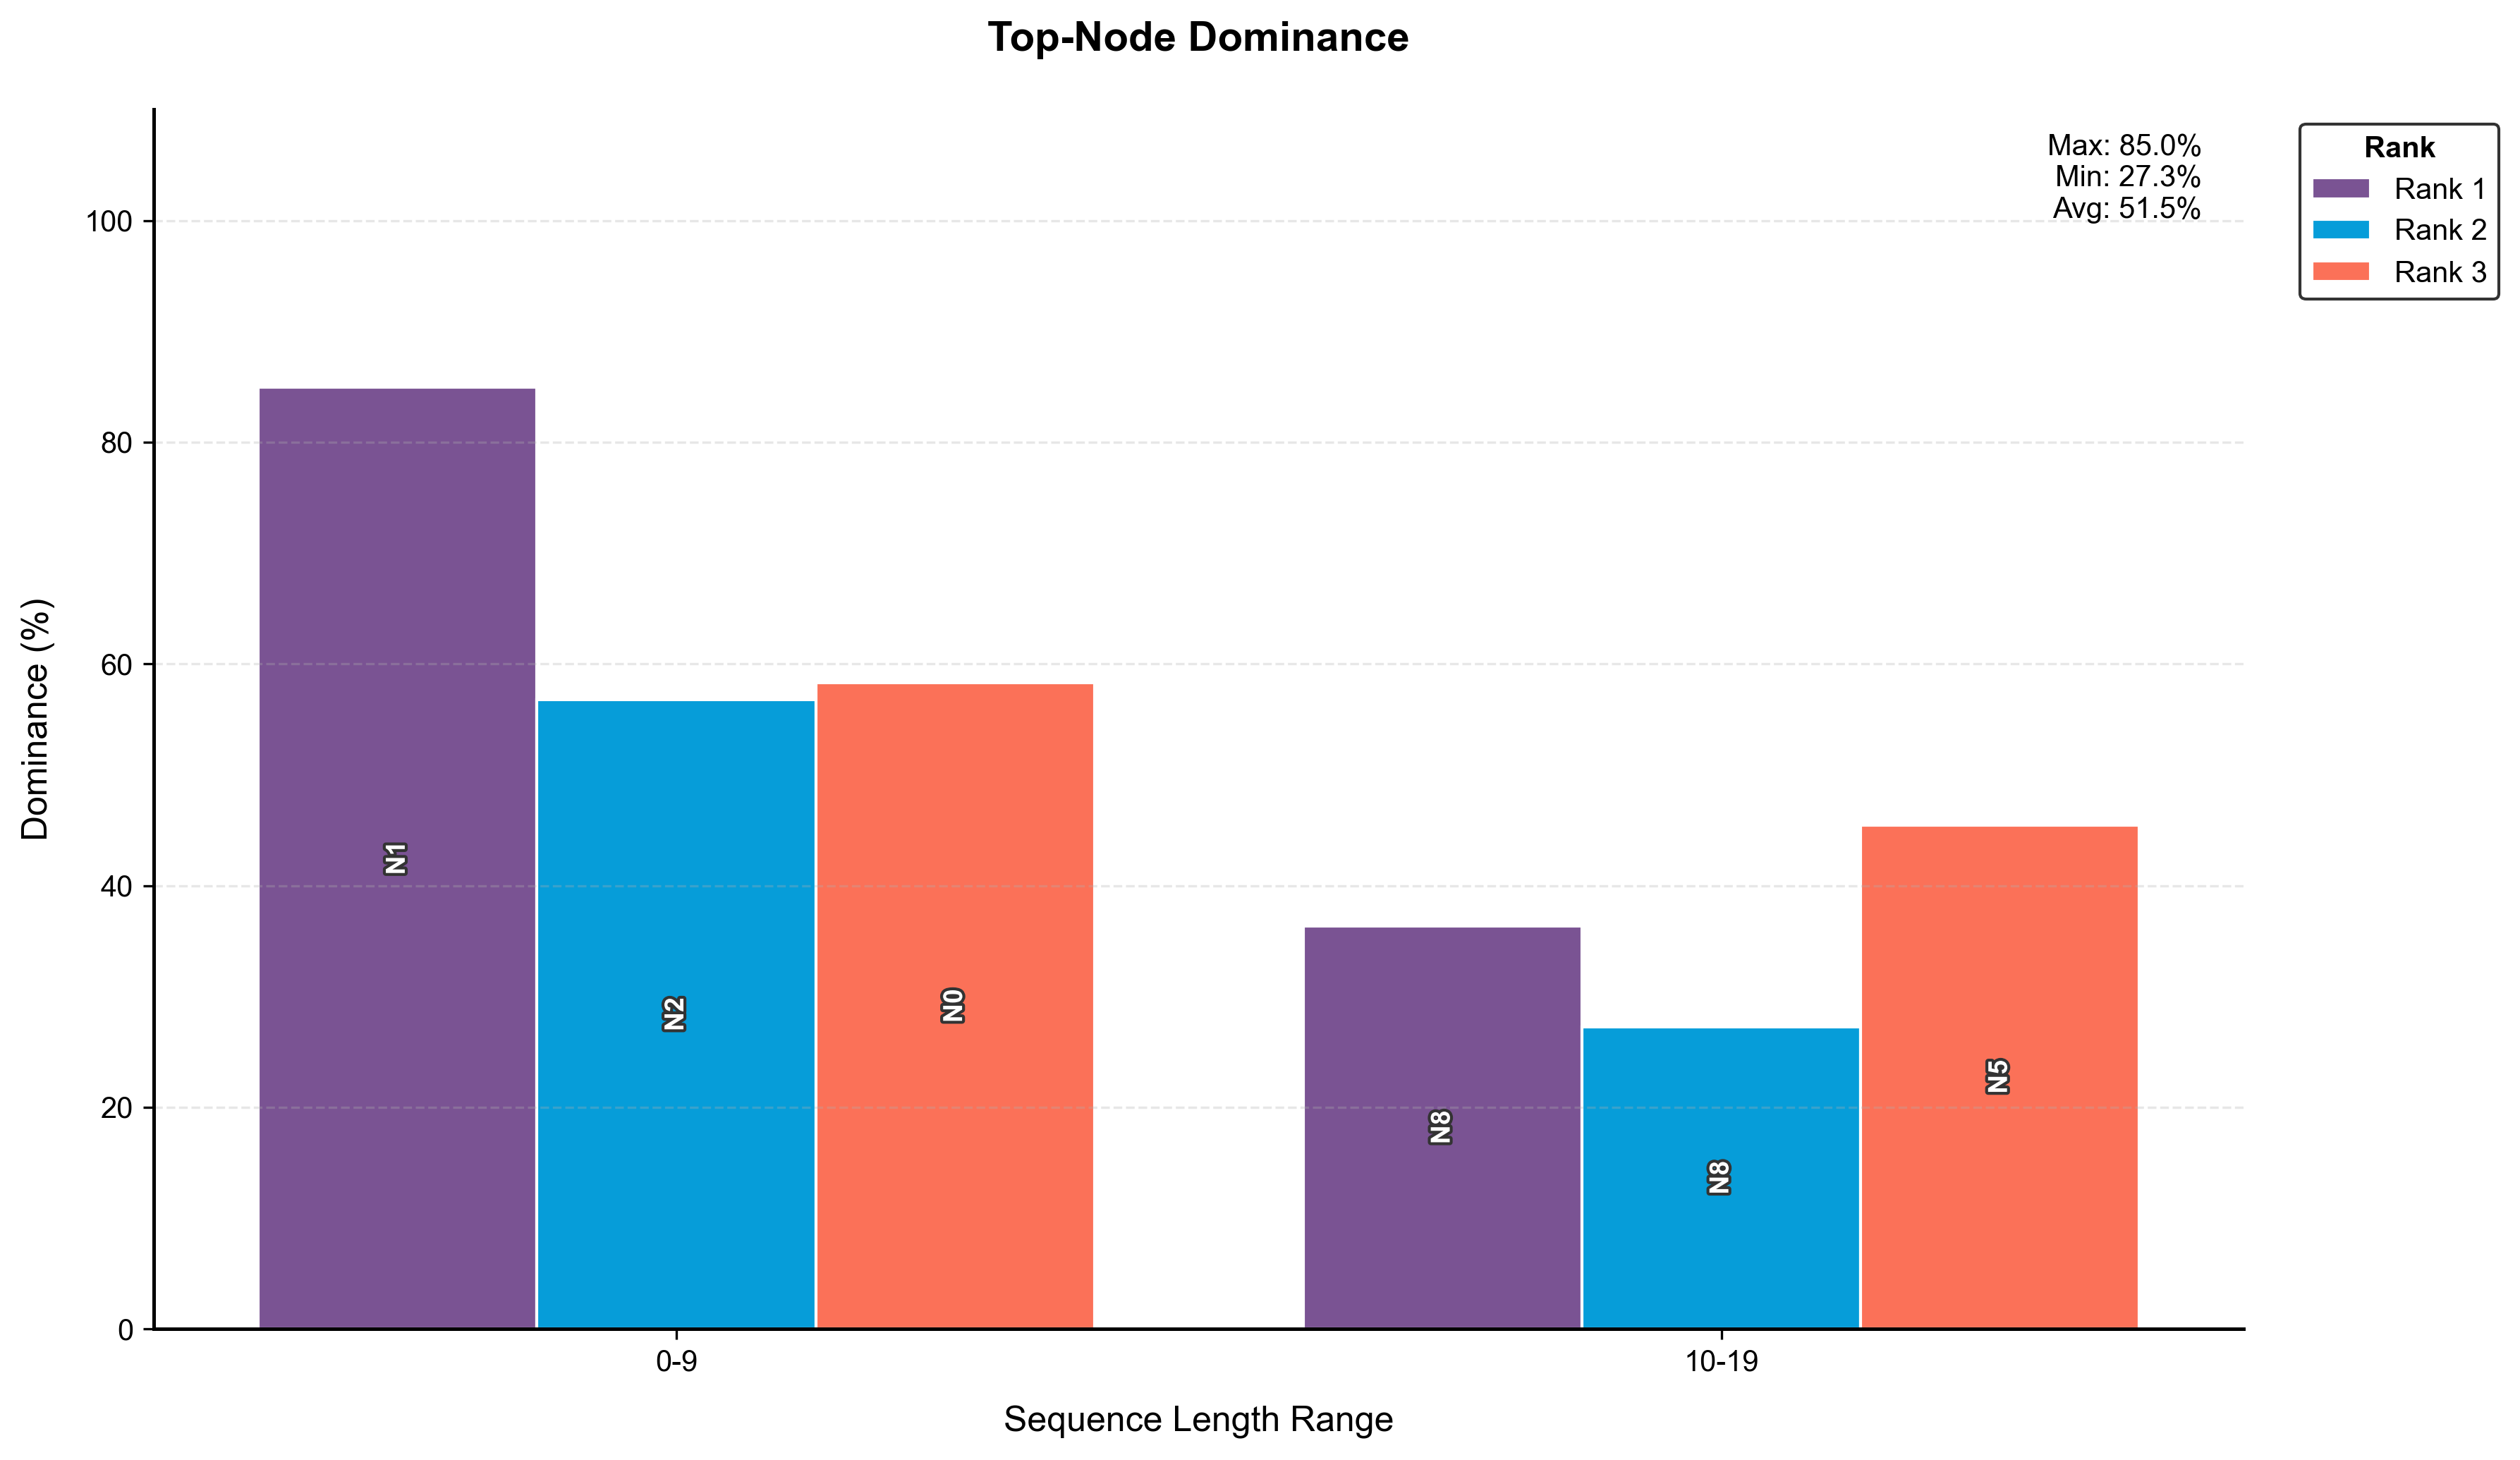

Missing decay/attention values; skip plot_importance_timeline_edge.
Missing edge-type scores; skip plot_edge_attention_correlation.


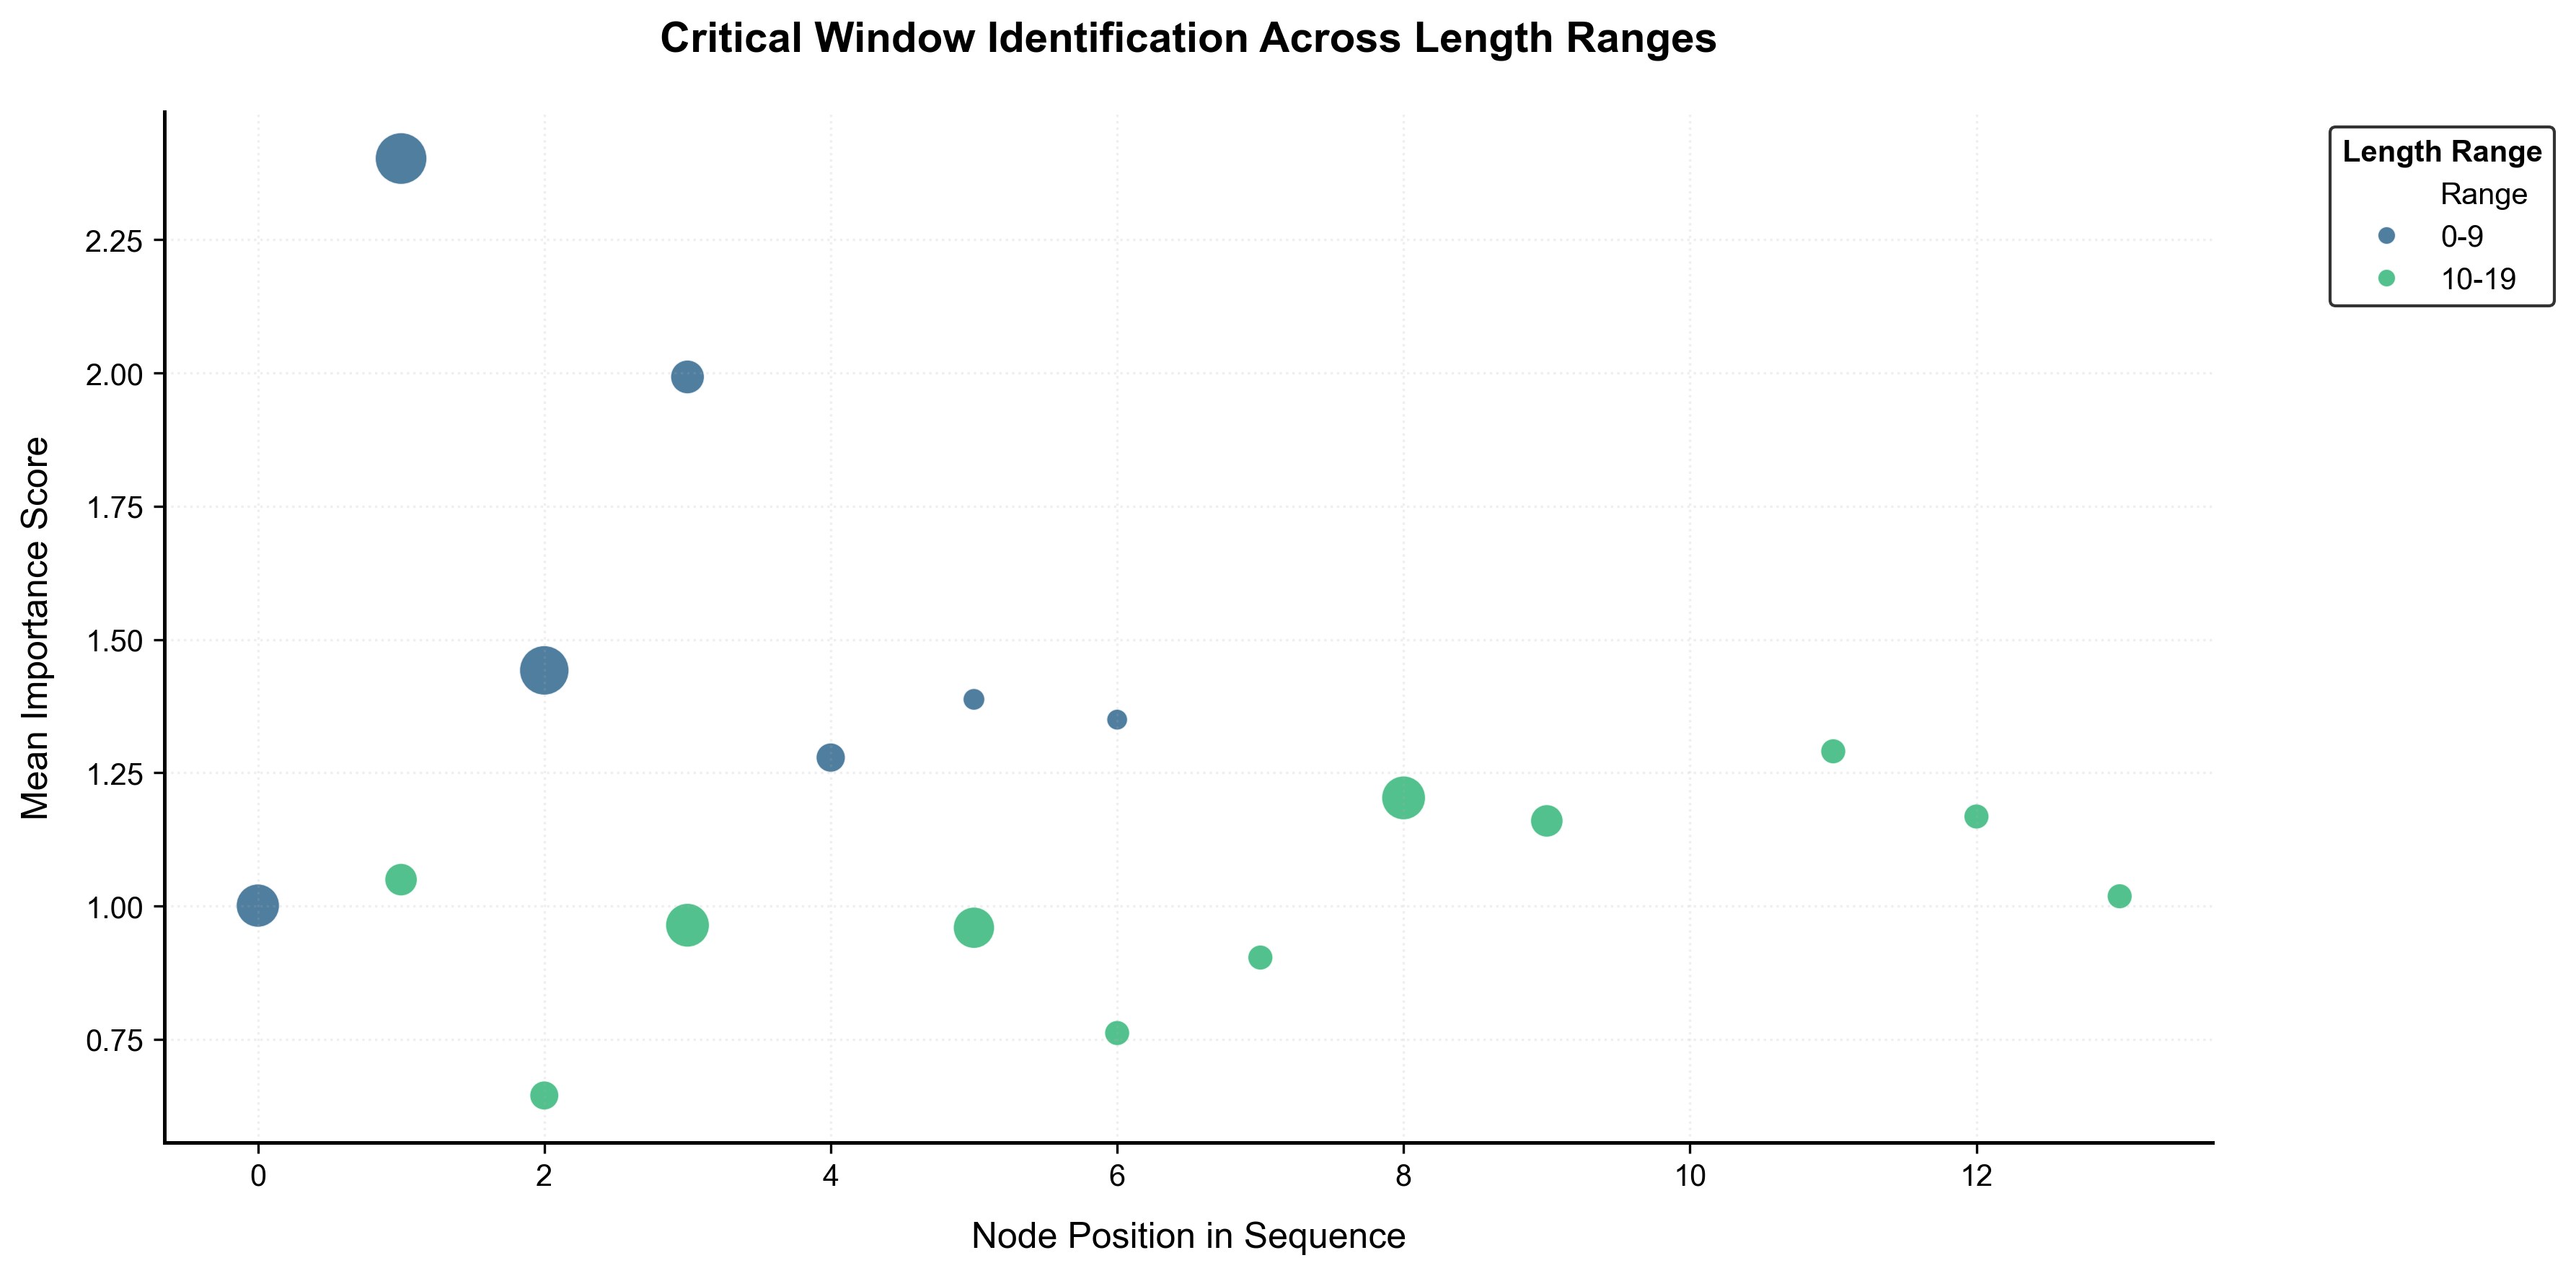

     Comparison Mean Diff t-statistic    p-value Cohen's d Significance  n1  \
0  0-9 vs 10-19     0.539        3.37  3.882e-03      1.63           **   7   

   n2  
0  11  


C:\Users\david\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


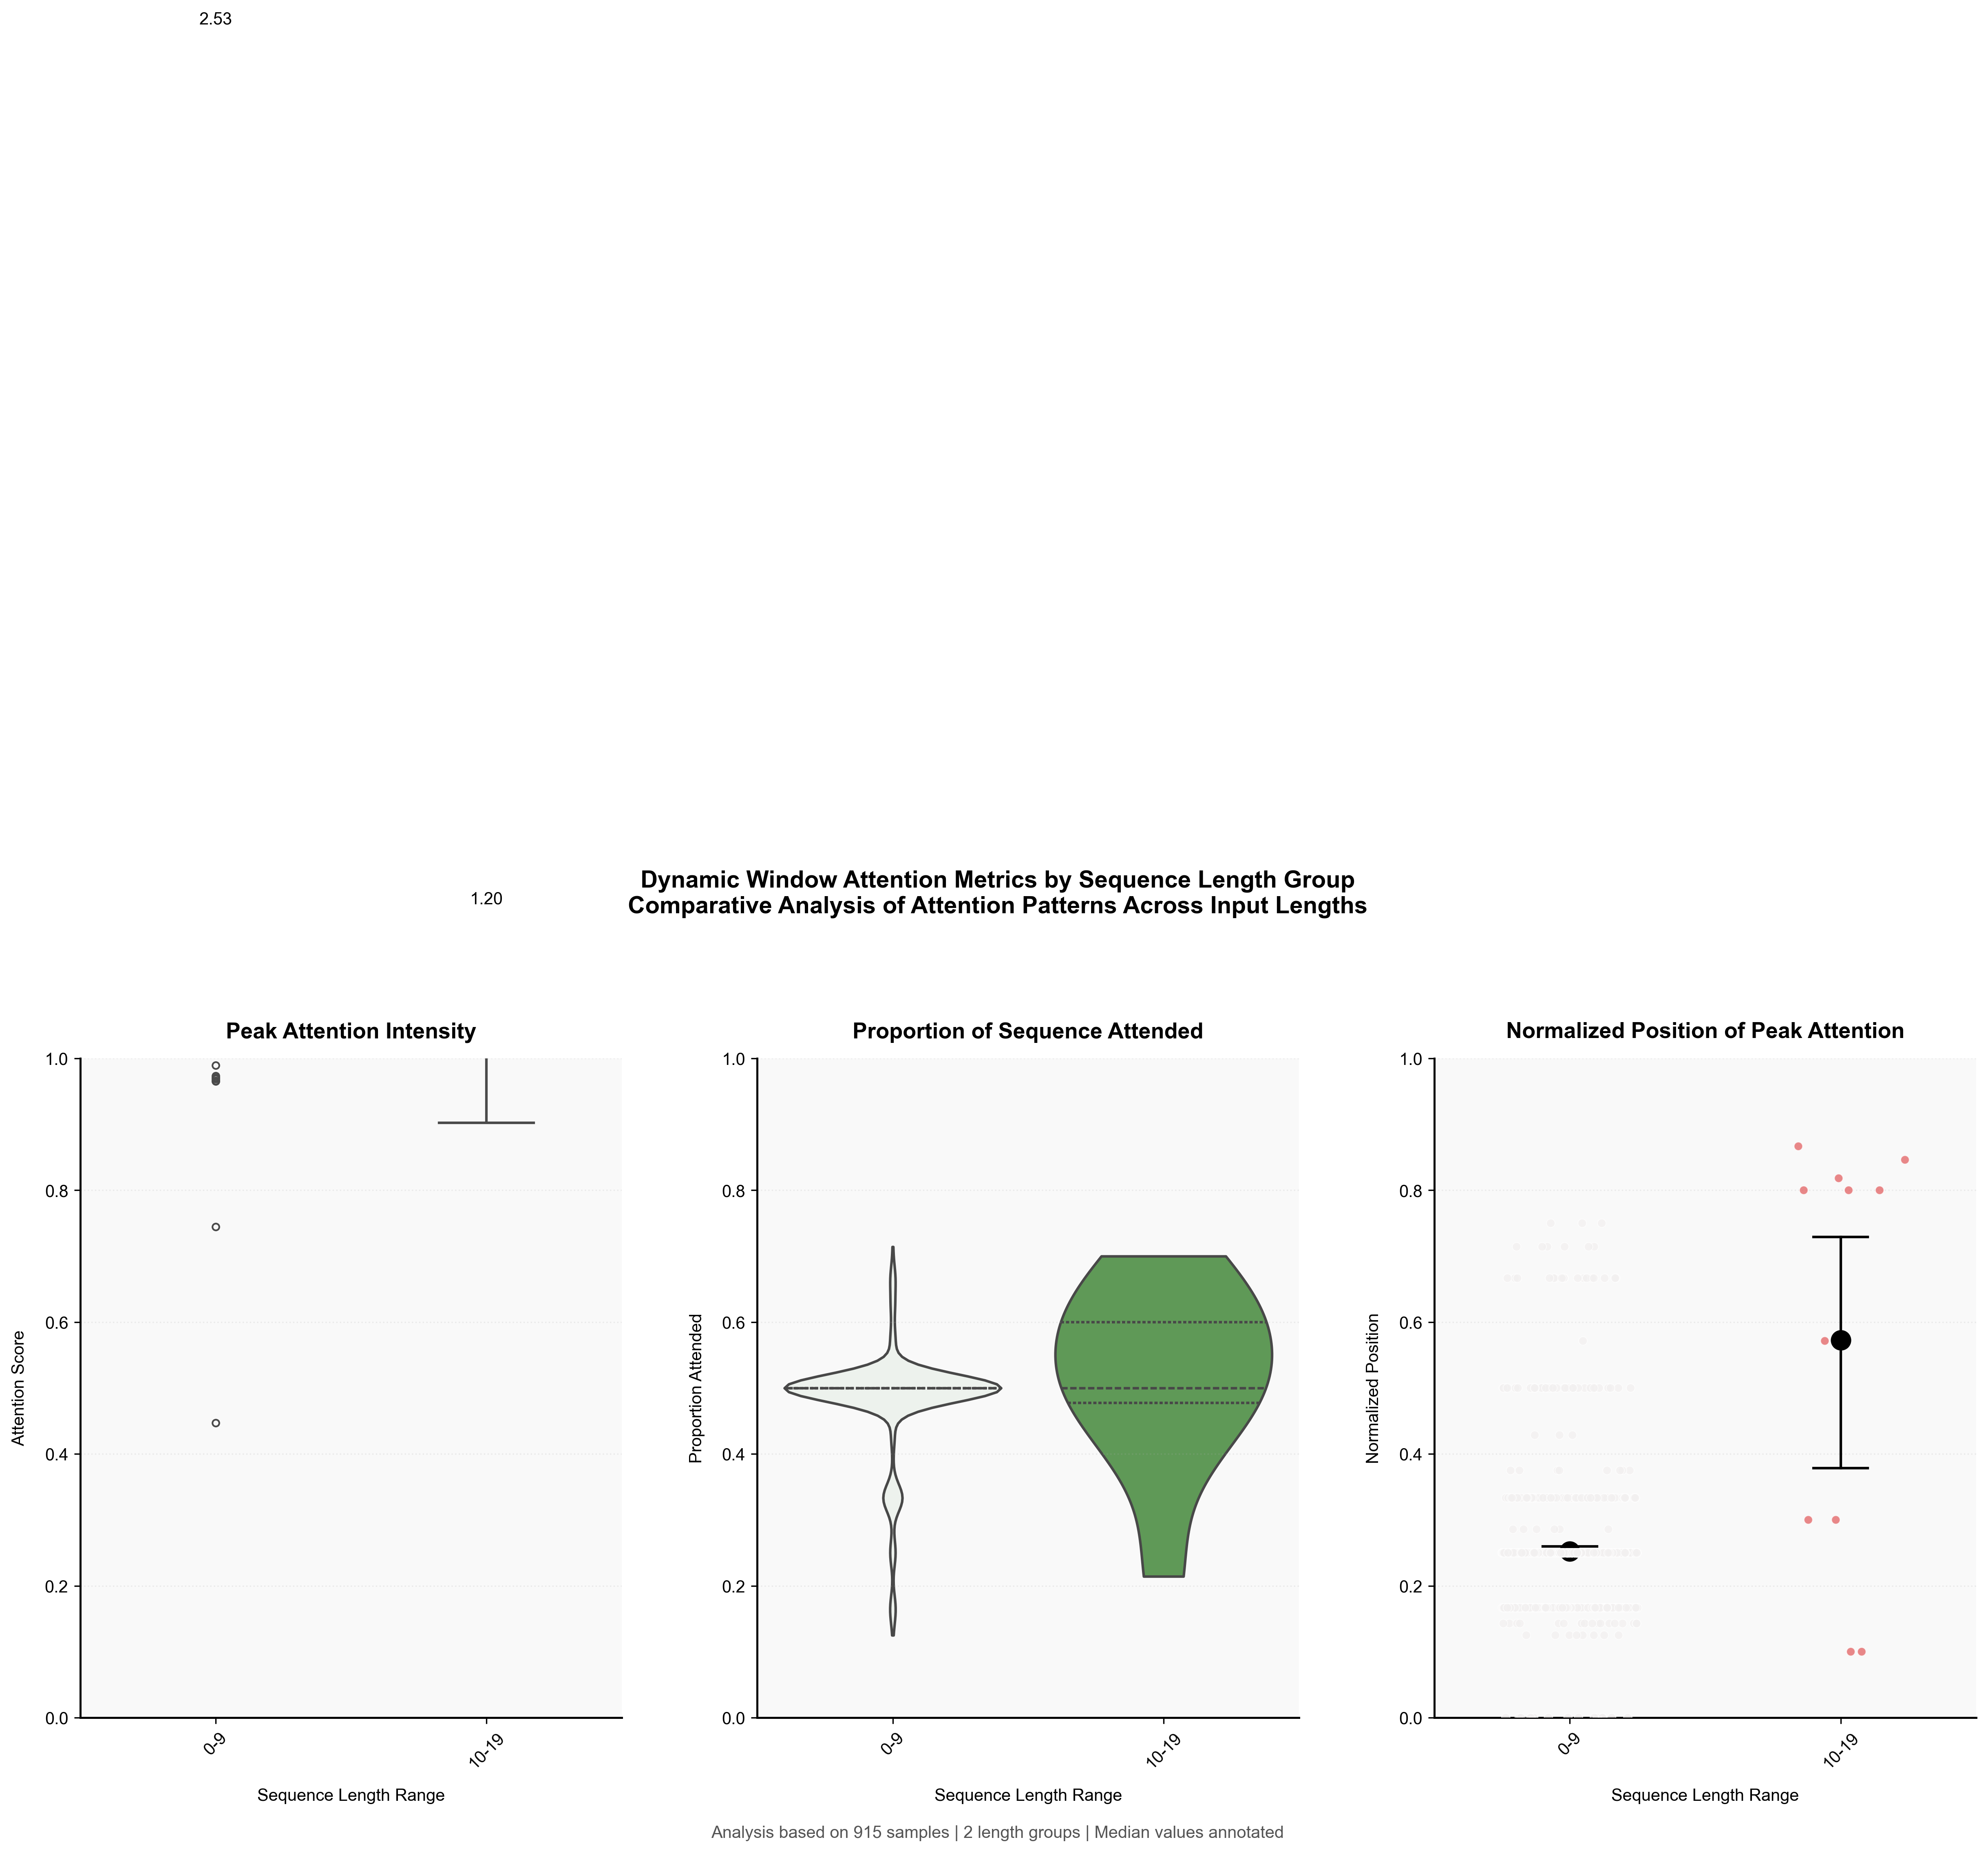

In [5]:
from timegnn import (
    get_length_bins_from_attention, compute_importance_stats,
    plot_heatmap_from_stats, plot_rank_dominance,
    plot_importance_timeline, plot_importance_timeline_edge,
    plot_edge_attention_correlation,
    plot_critical_windows, generate_pairwise_ttest_table,
    get_top_significant_ranges,
    calculate_window_metrics, plot_window_metrics,
)

attention = result.get("attention")

if attention:
    length_bins, _ = get_length_bins_from_attention(attention, bin_size=10)
    range_stats, range_importances, _ = compute_importance_stats(attention, length_bins)

    # ── Importance heatmap ──
    plot_heatmap_from_stats(range_stats, range_importances)

    # ── Rank dominance ──
    plot_rank_dominance(range_stats, title="Top-Node Dominance")

    # ── Importance timeline (with edge scores) ──
    plot_importance_timeline(attention, min_length=5, max_length=10)

    # ── Edge-attention correlation ──
    try:
        plot_edge_attention_correlation(attention, length_bins)
    except Exception as exc:
        print(f"Edge-attention correlation skipped: {exc}")

    # ── Statistical tests ──
    window_stats = plot_critical_windows(attention, length_bins, compare_ranges=None)
    pairwise = generate_pairwise_ttest_table(window_stats, length_bins)
    top_sig, _ = get_top_significant_ranges(pairwise, num_top=5)
    print(top_sig)

    df_metrics = calculate_window_metrics(attention, length_bins)
    plot_window_metrics(df_metrics)
else:
    print("No attention data was returned.")

## 5. Summary

The **Time-Aware GAT + Status Embedding** is the most expressive model in the library.
It captures:
- **Temporal dynamics** via learnable exponential decay (λ)
- **Transition semantics** via learned edge-type embeddings

The attention analysis reveals how these components interact to determine
which events in the process history are most predictive of the next step.